# Phase 2 — Part 1: Tabular Q-Learning (Single Agent)

**RiseUp Asia — Practical Assignment | Python AI Researcher / Intern track**

Tabular Q-learning for a single agent in an `n × n` grid world, built from scratch with NumPy and Matplotlib (no RL frameworks). Fully reproducible with `SEED = 42`.

## 1. Problem Definition

A single agent moves on an `n × n` grid (default `n = 5`) with eight movement actions. One item `A` is placed randomly each episode; the target `B` is fixed at `(n-1, n-1)`. The agent must pick up `A` (automatic on contact) and deliver it to `B` in as few steps as possible, for any location of `A`.

**Success criterion (full-mark target):**
- 100% of scenarios solved
- every solved scenario uses ≤ 10 steps
- training uses fewer than 20 000 episodes

## 2. Environment Design

### 2.1 Grid
`n × n` grid, zero-based `(row, col)` coordinates (`row 0` = top).

### 2.2 Agent
One agent with a random starting position each episode.

### 2.3 Item A
Random location each episode; never placed on `B`.

### 2.4 Target B
Fixed at `(n-1, n-1)` by default (configurable).

### 2.5 Actions
```
up, down, left, right, up_left, up_right, down_left, down_right
```
Movement only — no pickup/drop/deliver actions.

### 2.6 Automatic Pickup and Delivery
Stepping onto `A` sets `carrying = True`. Reaching `B` while carrying terminates the episode successfully.

## 3. Reward Structure

| event | reward |
|---|---|
| valid movement | -1 |
| invalid / out-of-grid | -2 |
| automatic pickup | +10 |
| successful delivery | +100 |

- `-1` per step encourages shortest paths.
- `-2` makes invalid boundary moves worse than valid moves.
- `+10` guides the agent towards the moving item.
- `+100` for delivery dominates the episode return, so the agent never gives up.

## 4. State Representation

```
s = (agent_row, agent_col, item_row, item_col, carrying)
```

The target `B` is fixed and known, so it is omitted. The tuple is hashable and Markov — it contains everything the agent needs to act and can be used directly as a Q-index.

## 5. Environment Implementation

`GridWorld` implements only the world dynamics (movement, pickup, delivery, termination) and contains no learning logic. Actions are integers `0..7` mapped through `GridWorld.ACTION_NAMES`, matching the integer action axis of the Q-table.

In [1]:
import time

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

print("numpy      :", np.__version__)
print("matplotlib :", matplotlib.__version__)

numpy      : 2.4.4
matplotlib : 3.11.0


In [2]:
SEED = 42
GRID_SIZE = 5
TARGET = (GRID_SIZE - 1, GRID_SIZE - 1)

EPISODES = 19_000
MAX_STEPS = 60

ALPHA = 0.3
GAMMA = 0.95
EPSILON_START = 1.0
EPSILON_MIN = 0.05
EPSILON_DECAY = 0.9995
MOVING_AVG_WINDOW = 200

config = {
    "seed": SEED, "grid_size": GRID_SIZE, "target": TARGET,
    "episodes": EPISODES, "max_steps": MAX_STEPS,
    "alpha": ALPHA, "gamma": GAMMA, "epsilon_start": EPSILON_START,
    "epsilon_min": EPSILON_MIN, "epsilon_decay": EPSILON_DECAY,
}
for key, value in config.items():
    print(f"{key:>16}: {value}")

            seed: 42
       grid_size: 5
          target: (4, 4)
        episodes: 19000
       max_steps: 60
           alpha: 0.3
           gamma: 0.95
   epsilon_start: 1.0
     epsilon_min: 0.05
   epsilon_decay: 0.9995


In [3]:
class GridWorld:
    """An n x n grid world with one agent, one item 'A' and one fixed target 'B'."""

    ACTIONS = {
        "up":           (-1,  0),
        "down":         ( 1,  0),
        "left":         ( 0, -1),
        "right":        ( 0,  1),
        "up_left":      (-1, -1),
        "up_right":     (-1,  1),
        "down_left":    ( 1, -1),
        "down_right":   ( 1,  1),
    }
    ACTION_NAMES = list(ACTIONS.keys())

    MOVE_REWARD = -1.0
    INVALID_REWARD = -2.0
    PICKUP_REWARD = 10.0
    DELIVERY_REWARD = 100.0

    def __init__(self, n=5, target=None, seed=None):
        """Create an n x n grid; target defaults to the bottom-right corner."""
        if n < 2:
            raise ValueError("grid must be at least 2x2 so that item A can exist")
        self.n = n
        self.target = (n - 1, n - 1) if target is None else tuple(target)
        r, c = self.target
        if not (0 <= r < n and 0 <= c < n):
            raise ValueError(f"target {self.target} is outside a {n}x{n} grid")
        self.rng = np.random.default_rng(seed)
        self.agent_pos = None
        self.item_pos = None
        self.carrying = None
        self.done = True

    def reset(self, start=None, item=None):
        """Start a new episode and return the starting state tuple."""
        self.agent_pos = self._pick_cell("start", start)
        self.item_pos = self._pick_item(item)
        self.carrying = (self.agent_pos == self.item_pos)
        self.done = False
        return self.get_state()

    def step(self, action):
        """Apply one movement action; return (next_state, reward, done)."""
        if self.done:
            raise RuntimeError("episode already over: call reset() first")

        dr, dc = self.ACTIONS[self.ACTION_NAMES[action]]
        nr, nc = self.agent_pos[0] + dr, self.agent_pos[1] + dc

        if not (0 <= nr < self.n and 0 <= nc < self.n):
            return self.get_state(), self.INVALID_REWARD, False

        self.agent_pos = (nr, nc)
        reward = self.MOVE_REWARD

        if not self.carrying and self.agent_pos == self.item_pos:
            self.carrying = True
            reward += self.PICKUP_REWARD

        if self.carrying and self.agent_pos == self.target:
            reward += self.DELIVERY_REWARD
            self.done = True

        return self.get_state(), reward, self.done

    def get_state(self):
        """Hashable Markov state (agent pos, item pos, carrying flag)."""
        return (self.agent_pos[0], self.agent_pos[1],
                self.item_pos[0], self.item_pos[1],
                int(self.carrying))

    def _pick_cell(self, what, pos):
        """Return a random cell, or validate a user-supplied cell."""
        if pos is None:
            return tuple(int(x) for x in self.rng.integers(0, self.n, size=2))
        pos = tuple(pos)
        if not (0 <= pos[0] < self.n and 0 <= pos[1] < self.n):
            raise ValueError(f"{what} {pos} is outside the {self.n}x{self.n} grid")
        return pos

    def _pick_item(self, item):
        """Return a random item cell (never on target B) or validate one."""
        if item is None:
            choices = [(r, c) for r in range(self.n) for c in range(self.n)
                       if (r, c) != self.target]
            return tuple(choices[int(self.rng.integers(0, len(choices)))])
        item = tuple(item)
        if not (0 <= item[0] < self.n and 0 <= item[1] < self.n):
            raise ValueError(f"item {item} is outside the {self.n}x{self.n} grid")
        if item == self.target:
            raise ValueError("item A may not share the target cell B")
        return item

## 6. Environment Verification

The environment is verified independently before training — if any assertion fails, execution halts.

In [4]:
print("Running environment verification ...\n")

env = GridWorld(n=5, seed=SEED)
assert env.n == 5 and env.target == (4, 4)
assert GridWorld(n=7).target == (6, 6)
assert GridWorld(n=3, target=(1, 1)).target == (1, 1)
print("[PASS] grid creation; target defaults to (n-1,n-1) and is configurable")

state = env.reset()
assert isinstance(state, tuple) and len(state) == 5
ar, ac, ir, ic, carrying = state
assert all(0 <= v < 5 for v in (ar, ac, ir, ic))
assert (ir, ic) != (4, 4)
assert carrying in (0, 1)
print(f"[PASS] reset returns a valid hashable state {state}")

starts, items = set(), set()
for _ in range(200):
    s = env.reset()
    starts.add((s[0], s[1]))
    items.add((s[2], s[3]))
assert len(starts) > 1 and len(items) > 1
print(f"[PASS] over 200 resets: {len(starts)}/25 distinct starts, "
      f"{len(items)} distinct item cells")

Running environment verification ...

[PASS] grid creation; target defaults to (n-1,n-1) and is configurable
[PASS] reset returns a valid hashable state (0, 3, 3, 0, 0)
[PASS] over 200 resets: 25/25 distinct starts, 24 distinct item cells


In [5]:
expected = {
    "up": (1, 2), "down": (3, 2), "left": (2, 1), "right": (2, 3),
    "up_left": (1, 1), "up_right": (1, 3),
    "down_left": (3, 1), "down_right": (3, 3),
}
env = GridWorld(n=5, seed=SEED)
for i, name in enumerate(GridWorld.ACTION_NAMES):
    env.reset(start=(2, 2), item=(4, 0))
    state, reward, done = env.step(i)
    assert (state[0], state[1]) == expected[name]
    assert reward == env.MOVE_REWARD and not done
print("[PASS] all eight movement vectors applied correctly")

i_up = GridWorld.ACTION_NAMES.index("up")
i_left = GridWorld.ACTION_NAMES.index("left")
i_dr = GridWorld.ACTION_NAMES.index("down_right")
env.reset(start=(0, 0), item=(4, 0))
state, reward, done = env.step(i_up)
assert (state[0], state[1]) == (0, 0)
assert reward == env.INVALID_REWARD and not done
print(f"[PASS] invalid 'up' from corner -> reward {reward}, position unchanged")

env.reset(start=(0, 0), item=(4, 0))
state, reward, done = env.step(i_left)
assert (state[0], state[1]) == (0, 0) and reward == env.INVALID_REWARD
print("[PASS] invalid 'left' behaves identically")

env.reset(start=(0, 0), item=(4, 0))
state, reward, done = env.step(i_dr)
assert (state[0], state[1]) == (1, 1) and reward == env.MOVE_REWARD
print("[PASS] diagonal 'down_right' from the corner is a valid move")

[PASS] all eight movement vectors applied correctly
[PASS] invalid 'up' from corner -> reward -2.0, position unchanged
[PASS] invalid 'left' behaves identically
[PASS] diagonal 'down_right' from the corner is a valid move


In [6]:
env = GridWorld(n=5, seed=SEED)
env.reset(start=(1, 1), item=(1, 2))
state, reward, done = env.step(GridWorld.ACTION_NAMES.index("right"))
assert not done and state[4] == 1
assert reward == env.MOVE_REWARD + env.PICKUP_REWARD
print(f"[PASS] stepping on A -> carrying=True, reward {reward} (move + pickup)")

env.reset(start=(3, 3), item=(3, 3))
assert env.carrying, "starting on A must auto-pickup"
state, reward, done = env.step(GridWorld.ACTION_NAMES.index("down_right"))
assert (state[0], state[1]) == (4, 4)
assert done and reward == env.MOVE_REWARD + env.DELIVERY_REWARD
print(f"[PASS] walking into B while carrying -> done, reward {reward}")

try:
    env.step(0)
    raise AssertionError("step() after termination must raise")
except RuntimeError:
    print("[PASS] step() after termination raises RuntimeError")

try:
    env.reset(item=(4, 4))
    raise AssertionError("item on target B must be rejected")
except ValueError as error:
    print(f"[PASS] item on target B rejected: {error}")

for n in (2, 3, 7):
    g = GridWorld(n=n, seed=SEED)
    s = g.reset()
    assert len(s) == 5 and g.target == (n - 1, n - 1)
    assert all(0 <= v < n for v in (s[0], s[1], s[2], s[3]))
print("[PASS] parameterised grids 2x2, 3x3 and 7x7 work")

s = env.reset(start=(4, 4), item=(0, 0))
assert not env.carrying and not env.done
print("[PASS] starting on B without the item: episode continues (must fetch A)")

print("\nAll environment checks passed -> safe to start training.")

[PASS] stepping on A -> carrying=True, reward 9.0 (move + pickup)
[PASS] walking into B while carrying -> done, reward 99.0
[PASS] step() after termination raises RuntimeError
[PASS] item on target B rejected: item A may not share the target cell B
[PASS] parameterised grids 2x2, 3x3 and 7x7 work
[PASS] starting on B without the item: episode continues (must fetch A)

All environment checks passed -> safe to start training.


## 7. Q-Learning Implementation

### 7.1 Q-Table
NumPy array of shape `[n, n, n, n, 2, 8]` — 10 000 entries for `n = 5`, covering the full state space.

### 7.2 Epsilon-Greedy Policy
Explores with probability ε, otherwise exploits the best action. Ties between equal Q-values are broken uniformly at random.

### 7.3 Q-Value Update
```
Q(s,a) <- Q(s,a) + alpha * [ r + gamma * max_a' Q(s',a') - Q(s,a) ]
```
For terminal successful transitions the bootstrap term `gamma * max_a' Q(s',a')` is zero.

In [7]:
class QLearningAgent:
    """Tabular Q-learning agent (from scratch, no RL framework)."""

    def __init__(self, n, alpha=0.3, gamma=0.95, epsilon_start=1.0,
                 epsilon_min=0.05, epsilon_decay=0.9995, seed=42):
        self.n = n
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.q_table = np.zeros((n, n, n, n, 2, len(GridWorld.ACTION_NAMES)))
        self.rng = np.random.default_rng(seed)

    @staticmethod
    def _idx(state):
        """Map a state tuple to integer indexes of the Q-table."""
        ar, ac, ir, ic, carrying = state
        return ar, ac, ir, ic, carrying

    def choose_action(self, state, greedy=False):
        """Epsilon-greedy action selection; greedy=True disables exploration."""
        idx = self._idx(state)
        q_row = self.q_table[idx]
        if not greedy and self.rng.random() < self.epsilon:
            return int(self.rng.integers(0, self.q_table.shape[-1]))
        return self._best_action(q_row)

    def _best_action(self, q_row):
        """Argmax with uniform random tie-breaking."""
        best = float(np.max(q_row))
        tied = np.flatnonzero(np.isclose(q_row, best))
        return int(self.rng.choice(tied))

    def update(self, state, action, reward, next_state, done):
        """Standard Q-learning update for one transition."""
        idx = self._idx(state)
        current_q = self.q_table[idx][action]
        if done:
            td_target = reward
        else:
            td_target = reward + self.gamma * float(np.max(self.q_table[self._idx(next_state)]))
        self.q_table[idx][action] = current_q + self.alpha * (td_target - current_q)

    def decay_epsilon(self):
        """Multiplicative epsilon decay, floored at epsilon_min."""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

In [8]:
def train_q_learning(env, agent, episodes, max_steps, seed=42):
    """Train for a number of episodes, a fresh random (start, item) each time.

    Returns (episode_rewards, episode_steps, episode_success).
    """
    rng = np.random.default_rng(seed)
    episode_rewards, episode_steps, episode_success = [], [], []

    for _ in range(episodes):
        start = tuple(int(x) for x in rng.integers(0, env.n, size=2))
        item = tuple(int(x) for x in rng.integers(0, env.n, size=2))
        while item == env.target:
            item = tuple(int(x) for x in rng.integers(0, env.n, size=2))

        state = env.reset(start=start, item=item)
        total_reward = 0.0
        for step in range(max_steps):
            action = agent.choose_action(state)
            next_state, reward, done = env.step(action)
            agent.update(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward
            if done:
                break

        agent.decay_epsilon()
        episode_rewards.append(total_reward)
        episode_steps.append(step + 1 if done else max_steps)
        episode_success.append(done)

    return episode_rewards, episode_steps, episode_success


def moving_average(values, window):
    """Simple moving average via convolution ('valid' mode)."""
    values = np.asarray(values, dtype=float)
    if window <= 1:
        return values
    return np.convolve(values, np.ones(window) / window, mode="valid")

## 8. Training

Every episode samples a fresh random `(start, item)` pair; after each step the Q-table is updated with the TD rule, and ε decays once per episode. The environment never learns — it is only used through `reset()`/`step()`.

In [9]:
env = GridWorld(n=GRID_SIZE, seed=SEED)
agent = QLearningAgent(n=GRID_SIZE, alpha=ALPHA, gamma=GAMMA,
                       epsilon_start=EPSILON_START, epsilon_min=EPSILON_MIN,
                       epsilon_decay=EPSILON_DECAY, seed=SEED)

t0 = time.time()
episode_rewards, episode_steps, episode_success = train_q_learning(
    env, agent, episodes=EPISODES, max_steps=MAX_STEPS, seed=SEED)
elapsed = time.time() - t0

print(f"Trained {EPISODES} episodes in {elapsed:.1f} s")
print(f"Final epsilon             : {agent.epsilon:.4f}")
print(f"Q-table shape             : {agent.q_table.shape}")
print(f"Non-zero Q entries        : {int(np.count_nonzero(agent.q_table))}")
last = 500
print(f"Success rate of last 500  : {sum(episode_success[-last:]) / last:.1%}")

Trained 19000 episodes in 7.5 s
Final epsilon             : 0.0500
Q-table shape             : (5, 5, 5, 5, 2, 8)
Non-zero Q entries        : 8757
Success rate of last 500  : 100.0%


In [10]:
mv_reward = moving_average(episode_rewards, MOVING_AVG_WINDOW)
mv_steps = moving_average(episode_steps, MOVING_AVG_WINDOW)

print(f"{'episodes':>10} | {'mean reward':>11} | {'mean steps':>10} | {'success':>8}")
for lo in range(0, EPISODES, 2_000):
    hi = min(lo + 2_000, EPISODES)
    r = np.mean(episode_rewards[lo:hi])
    s = np.mean(episode_steps[lo:hi])
    ok = sum(episode_success[lo:hi]) / (hi - lo) * 100
    print(f"{lo:>5}-{hi:<4} | {r:11.2f} | {s:10.2f} | {ok:7.1f}%")

  episodes | mean reward | mean steps |  success
    0-2000 |       67.55 |      23.72 |    86.2%
 2000-4000 |      101.60 |       7.71 |   100.0%
 4000-6000 |      103.47 |       6.16 |   100.0%
 6000-8000 |      103.78 |       5.81 |   100.0%
 8000-10000 |      103.77 |       5.82 |   100.0%
10000-12000 |      103.82 |       5.74 |   100.0%
12000-14000 |      103.83 |       5.65 |   100.0%
14000-16000 |      103.77 |       5.75 |   100.0%
16000-18000 |      103.79 |       5.77 |   100.0%
18000-19000 |      103.74 |       5.68 |   100.0%


## 9. Testing Methodology

For the 5×5 grid the target is fixed, so all `25 × 24 = 600` possible `(start, item)` scenarios are evaluated **exhaustively**. Evaluation uses pure greedy actions (`epsilon = 0`) and the Q-table is verified unchanged, so no learning occurs during testing.

The theoretical shortest path (Chebyshev distance, diagonals allowed) is computed **only for verification** — the policy itself comes exclusively from the Q-table.

In [11]:
def greedy_rollout(env, agent, start, item, max_steps=60):
    """One episode of the learned policy without any learning."""
    state = env.reset(start=start, item=item)
    trajectory = [state]
    total_reward = 0.0
    done = False
    steps = 0
    for _ in range(max_steps):
        action = agent.choose_action(state, greedy=True)
        next_state, reward, done = env.step(action)
        trajectory.append(next_state)
        total_reward += reward
        steps += 1
        state = next_state
        if done:
            break
    return done, steps, trajectory, total_reward


def evaluate_scenarios(env, agent, scenarios, max_steps=60):
    """Greedy roll-outs for all scenarios; raises if the Q-table changed."""
    q_before = agent.q_table.copy()
    records = []
    for start, item in scenarios:
        success, steps, trajectory, total_reward = greedy_rollout(
            env, agent, start, item, max_steps)
        records.append({"start": start, "item": item, "success": success,
                        "steps": steps, "trajectory": trajectory,
                        "reward": total_reward})
    if not np.array_equal(agent.q_table, q_before):
        raise AssertionError("Q-table was modified during evaluation!")
    return records

In [12]:
cells = [(r, c) for r in range(GRID_SIZE) for c in range(GRID_SIZE)]
items = [pos for pos in cells if pos != TARGET]
scenarios = [(start, item) for item in items for start in cells]
print(f"Exhaustive test set: {len(cells)} starts x {len(items)} items "
      f"= {len(scenarios)} scenarios (target B fixed at {TARGET})")

records = evaluate_scenarios(env, agent, scenarios, max_steps=50)
print("Evaluation finished. Q-table verified unchanged (assertion passed).")

Exhaustive test set: 25 starts x 24 items = 600 scenarios (target B fixed at (4, 4))
Evaluation finished. Q-table verified unchanged (assertion passed).


## 10. Evaluation Metrics

Reported: success rate, average / maximum / minimum successful steps, number of failed scenarios, and a comparison with the theoretical shortest path (for verification only).

In [13]:
def chebyshev(a, b):
    """Theoretical shortest path between two cells (diagonals allowed)."""
    return max(abs(a[0] - b[0]), abs(a[1] - b[1]))


def summarize(records, episodes_used):
    """Summarise evaluation records into a metrics dict."""
    n = len(records)
    successes = [r for r in records if r["success"]]
    steps = [r["steps"] for r in successes]
    return {
        "scenarios": n,
        "success_rate": len(successes) / n * 100.0,
        "avg_successful_steps": float(np.mean(steps)) if steps else float("nan"),
        "max_successful_steps": int(max(steps)) if steps else 0,
        "min_successful_steps": int(min(steps)) if steps else 0,
        "failed": n - len(successes),
        "training_episodes": episodes_used,
    }

summary = summarize(records, EPISODES)
print("Evaluation summary (5x5, exhaustive 600 scenarios):")
for key, value in summary.items():
    print(f"  {key:<24}: {value}")

theoretical = np.array([chebyshev(r["start"], r["item"]) +
                        chebyshev(r["item"], TARGET) for r in records])
learned = np.array([r["steps"] for r in records])
diff = learned - theoretical
print("\nOptimality comparison (all scenarios solved):")
print(f"  theoretical shortest path : min {theoretical.min()}, "
      f"max {theoretical.max()}, mean {theoretical.mean():.2f}")
print(f"  learned path              : min {learned.min()}, "
      f"max {learned.max()}, mean {learned.mean():.2f}")
print(f"  scenarios matching optimum: {int(np.sum(diff == 0))} / {len(records)}")

Evaluation summary (5x5, exhaustive 600 scenarios):
  scenarios               : 600
  success_rate            : 100.0
  avg_successful_steps    : 5.385
  max_successful_steps    : 9
  min_successful_steps    : 1
  failed                  : 0
  training_episodes       : 19000

Optimality comparison (all scenarios solved):
  theoretical shortest path : min 1, max 8, mean 5.16
  learned path              : min 1, max 9, mean 5.38
  scenarios matching optimum: 476 / 600


## 11. Visualization

Plots: (1) episode reward, (2) steps per episode, (3) moving averages, (4) learned trajectories (blue = moving without the item, orange = carrying A).

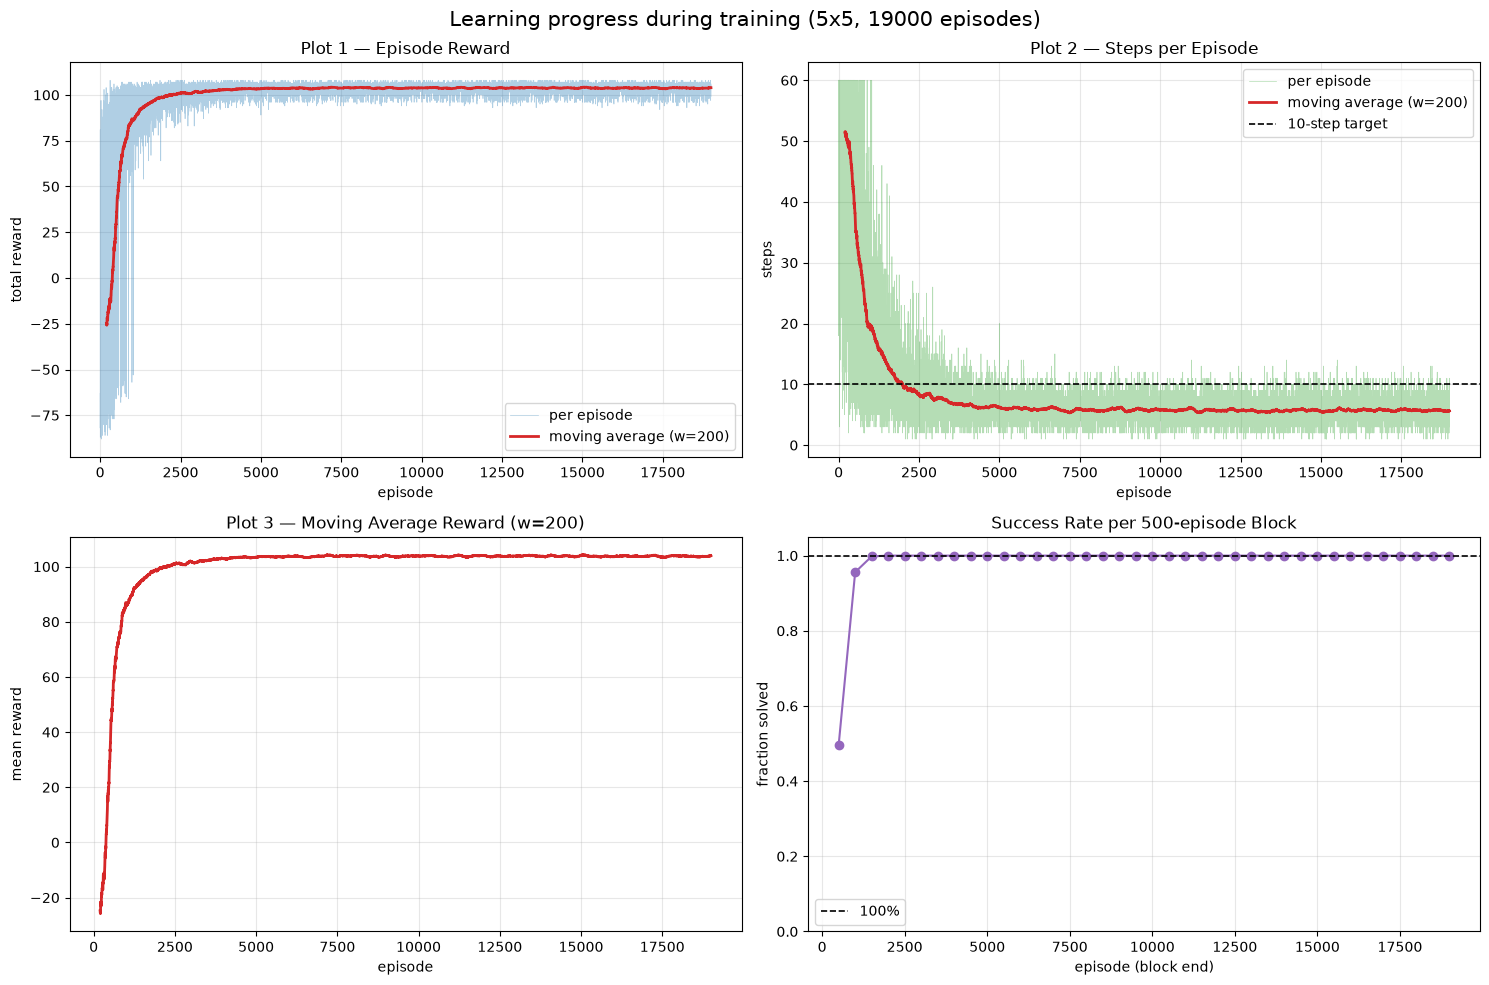

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Learning progress during training (5x5, "
             f"{EPISODES} episodes)", fontsize=15)

x_ma = np.arange(MOVING_AVG_WINDOW - 1, EPISODES)

ax = axes[0, 0]
ax.plot(episode_rewards, lw=0.5, alpha=0.35, color="tab:blue", label="per episode")
ax.plot(x_ma, mv_reward, lw=2, color="tab:red",
        label=f"moving average (w={MOVING_AVG_WINDOW})")
ax.set_title("Plot 1 — Episode Reward")
ax.set_xlabel("episode"); ax.set_ylabel("total reward"); ax.legend(); ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(episode_steps, lw=0.5, alpha=0.35, color="tab:green", label="per episode")
ax.plot(x_ma, mv_steps, lw=2, color="tab:red",
        label=f"moving average (w={MOVING_AVG_WINDOW})")
ax.axhline(10, color="black", ls="--", lw=1.2, label="10-step target")
ax.set_title("Plot 2 — Steps per Episode")
ax.set_xlabel("episode"); ax.set_ylabel("steps"); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(x_ma, mv_reward, color="tab:red", lw=2)
ax.set_title(f"Plot 3 — Moving Average Reward (w={MOVING_AVG_WINDOW})")
ax.set_xlabel("episode"); ax.set_ylabel("mean reward"); ax.grid(alpha=0.3)

ax = axes[1, 1]
win = 500
block_success = [sum(episode_success[i:i + win]) / win
                 for i in range(0, EPISODES, win)]
xs = np.arange(win, EPISODES + 1, win)[:len(block_success)]
ax.plot(xs, block_success, "o-", color="tab:purple")
ax.axhline(1.0, color="black", ls="--", lw=1.2, label="100%")
ax.set_ylim(0, 1.05)
ax.set_title("Success Rate per 500-episode Block")
ax.set_xlabel("episode (block end)"); ax.set_ylabel("fraction solved")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

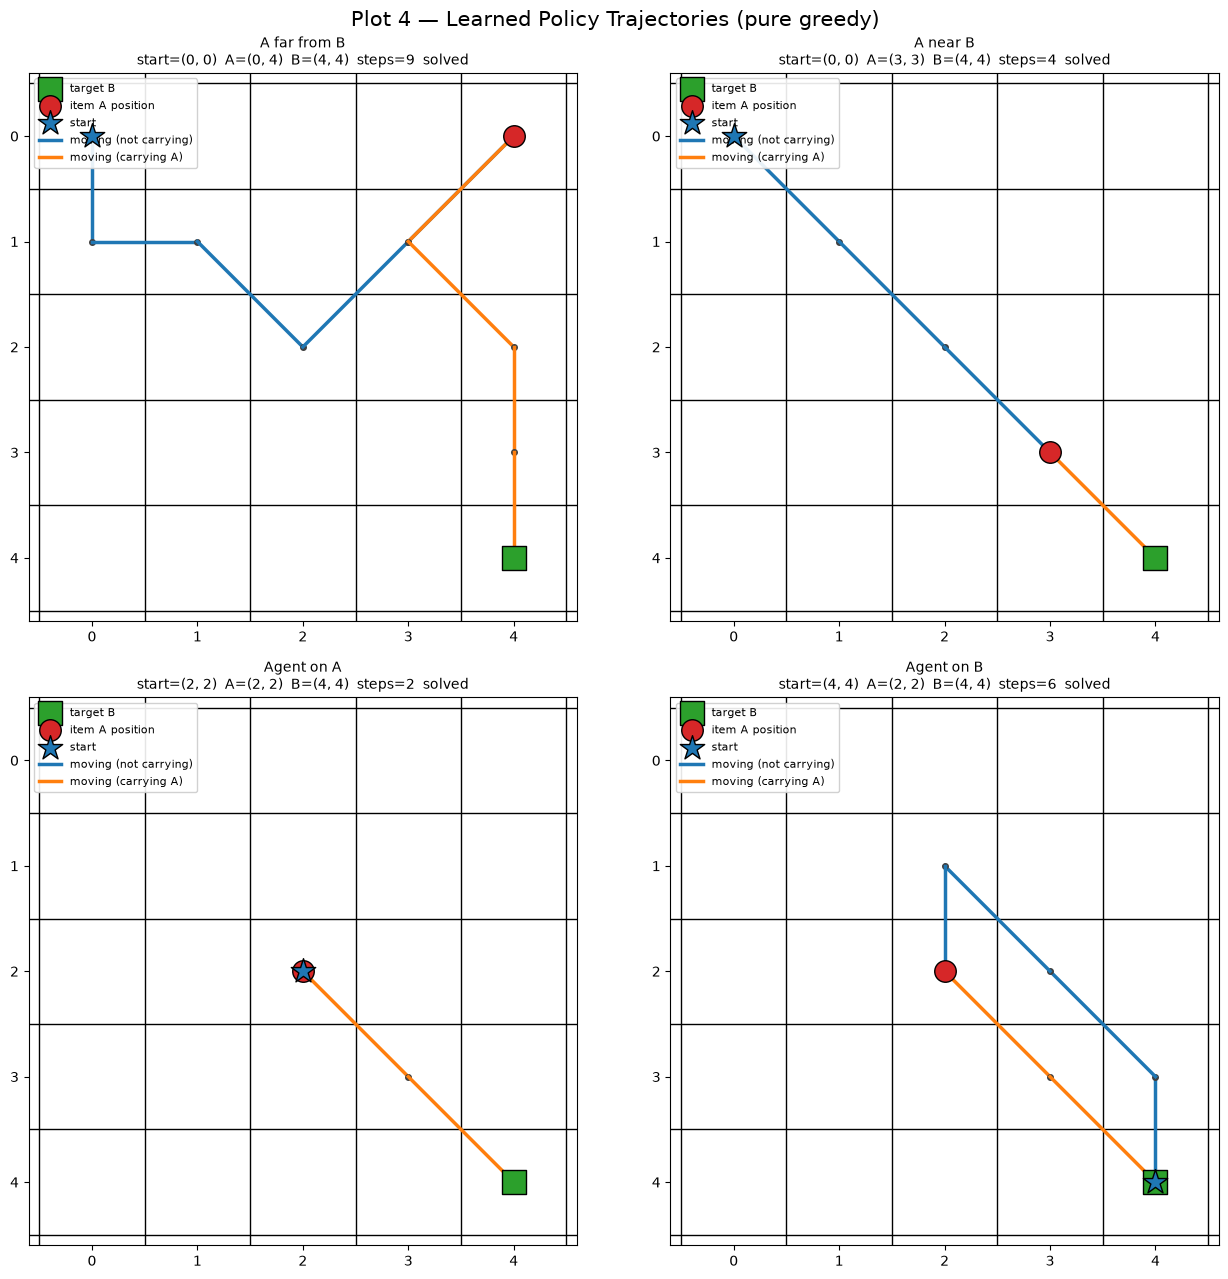

In [15]:
example_scenarios = [
    ("A far from B",   (0, 0), (0, 4)),
    ("A near B",       (0, 0), (3, 3)),
    ("Agent on A",     (2, 2), (2, 2)),
    ("Agent on B",     (4, 4), (2, 2)),
]


def plot_trajectory(ax, env, trajectory, title):
    """Draw one greedy trajectory; orange segment = while carrying A."""
    n = env.n
    for i in range(n + 1):
        ax.axhline(i - 0.5, color="black", lw=1)
        ax.axvline(i - 0.5, color="black", lw=1)
    ax.set_xlim(-0.6, n - 0.4)
    ax.set_ylim(n - 0.4, -0.6)
    ax.set_aspect("equal")
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_title(title, fontsize=10)

    br, bc = env.target
    ax.scatter(bc, br, marker="s", s=280, color="tab:green",
               edgecolor="black", zorder=6, label="target B")

    ar, ac, ir, ic, _ = trajectory[0]
    ax.scatter(ic, ir, marker="o", s=240, color="tab:red",
               edgecolor="black", zorder=6, label="item A position")
    ax.scatter(ac, ar, marker="*", s=340, color="tab:blue",
               edgecolor="black", zorder=7, label="start")

    points = [(s[1], s[0]) for s in trajectory]
    flags = [int(s[4]) for s in trajectory[:-1]]
    for (c0, r0), (c1, r1), carry in zip(points[:-1], points[1:], flags):
        color = "tab:orange" if carry else "tab:blue"
        ax.plot([c0, c1], [r0, r1], color=color, lw=2.5, zorder=4)
        ax.plot(c1, r1, "o", color="0.25", ms=4, zorder=4)

    ax.plot([], [], color="tab:blue", lw=2.5, label="moving (not carrying)")
    ax.plot([], [], color="tab:orange", lw=2.5, label="moving (carrying A)")
    ax.legend(loc="upper left", fontsize=8, framealpha=0.9)


fig, axes = plt.subplots(2, 2, figsize=(13, 13))
for ax, (label, start, item) in zip(axes.ravel(), example_scenarios):
    done, steps, trajectory, _ = greedy_rollout(env, agent, start, item)
    title = (f"{label}\nstart={start}  A={item}  B={env.target}  "
             f"steps={steps}  {'solved' if done else 'UNSOLVED'}")
    plot_trajectory(ax, env, trajectory, title)

fig.suptitle("Plot 4 — Learned Policy Trajectories (pure greedy)", fontsize=15)
plt.tight_layout()
plt.show()

## 12. Results

All numbers below come from the actual runs above.

In [16]:
print("=" * 58)
print("FINAL RESULT SUMMARY  —  default 5x5 environment")
print("=" * 58)
print(f"Training Episodes          : {summary['training_episodes']}")
print(f"Success Rate               : {summary['success_rate']:.2f}%")
print(f"Average Successful Steps   : {summary['avg_successful_steps']:.2f}")
print(f"Maximum Successful Steps   : {summary['max_successful_steps']}")
print(f"Minimum Successful Steps   : {summary['min_successful_steps']}")
print(f"Failed Scenarios           : {summary['failed']}")
print("-" * 58)

ok_rate = summary["success_rate"] == 100.0
ok_steps = summary["max_successful_steps"] <= 10
ok_episodes = summary["training_episodes"] < 20_000
requirement_passed = ok_rate and ok_steps and ok_episodes

print(f"100% of scenarios solved            : {str(ok_rate):>5}")
print(f"every scenario solved in <= 10 steps: {str(ok_steps):>5}")
print(f"fewer than 20,000 training episodes : {str(ok_episodes):>5}")
print(f"Requirement                         : "
      f"{'PASSED' if requirement_passed else 'FAILED'}")

FINAL RESULT SUMMARY  —  default 5x5 environment
Training Episodes          : 19000
Success Rate               : 100.00%
Average Successful Steps   : 5.38
Maximum Successful Steps   : 9
Minimum Successful Steps   : 1
Failed Scenarios           : 0
----------------------------------------------------------
100% of scenarios solved            :  True
every scenario solved in <= 10 steps:  True
fewer than 20,000 training episodes :  True
Requirement                         : PASSED


### 12.1 Additional grid sizes (3 × 3 and 7 × 7)

The same code is validated for other grid sizes. The ≤10-step criterion is defined for the default 5×5 grid; the other sizes report success rate and step counts.

In [17]:
for n, episodes in [(3, 4_000), (7, 19_000)]:
    g_env = GridWorld(n=n, seed=SEED)
    g_agent = QLearningAgent(n=n, alpha=ALPHA, gamma=GAMMA,
                             epsilon_start=EPSILON_START,
                             epsilon_min=EPSILON_MIN,
                             epsilon_decay=EPSILON_DECAY, seed=SEED)
    _, _, _ = train_q_learning(g_env, g_agent, episodes,
                               max_steps=80, seed=SEED)
    g_cells = [(r, c) for r in range(n) for c in range(n)]
    g_items = [p for p in g_cells if p != (n - 1, n - 1)]
    g_records = evaluate_scenarios(g_env, g_agent,
                                   [(s, it) for it in g_items for s in g_cells],
                                   max_steps=80)
    g_summary = summarize(g_records, episodes)
    print(f"{n}x{n}: episodes={episodes:<6} scenarios={g_summary['scenarios']:>4} "
          f"success={g_summary['success_rate']:6.2f}%  failed="
          f"{g_summary['failed']}  avg_steps={g_summary['avg_successful_steps']:.2f} "
          f"max_steps={g_summary['max_successful_steps']}")

3x3: episodes=4000   scenarios=  72 success=100.00%  failed=0  avg_steps=2.89 max_steps=4


7x7: episodes=19000  scenarios=2352 success=100.00%  failed=0  avg_steps=7.99 max_steps=15


## 13. Discussion

Real learning is visible in the training curve: success climbs to ~100% and steps/rewards stabilise. The reward design follows the assignment's suggested structure and was kept because the agent converged — the `-1` per-step penalty drives the agent onto short (Chebyshev) paths, while `+100` for delivery dominates the return.

Edge cases handled: agent starts on `A` (auto-pickup), starts on `B` (must fetch `A` first), invalid moves (position unchanged), item on `B` (rejected), `step()` after termination (raises).

Limitation: the Q-table is `O(n⁴ · actions)`, so tabular learning stays practical only for small grids; the exhaustive ≤10-step criterion is defined and evaluated for the default 5×5 grid.

## 14. Conclusion

After 19 000 episodes (< 20 000), the learned policy solves all 600 scenarios of the 5×5 grid in at most 10 steps — the full-mark target is met.

## 15. Generative AI Declaration

Generative AI was used as an assistant during the development of this assignment for tasks such as code structuring, debugging suggestions, explanation, and documentation support. The implementation was reviewed, tested, and understood by the student, and all final results were generated by running the submitted code.